<a href="https://colab.research.google.com/github/Felixvoz/Shines_Ouessant_GBOML_Model.ipynb/blob/main/Shines_Ouessant_GBOML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# SHINES – GBOML model for Ouessant
# Installation de l'environnement
# ==========================================

!pip install gboml
!pip install highspy
!pip install pandas numpy matplotlib openpyxl

print("Installation terminée")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 3.5 MB/s eta 0:00:00
Installation terminée


In [2]:
# ==========================================
# Imports et vérification de l'environnement
# ==========================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!python -m gboml --version

print("Dossier de travail :", os.getcwd())
print("Contenu actuel :", os.listdir())

/usr/bin/python3: No module named gboml.__main__; 'gboml' is a package and cannot be directly executed
Dossier de travail : /content
Contenu actuel : ['.config', 'sample_data']


In [3]:
# ==========================================
# Création des dossiers
# ==========================================

folders = ["data", "models", "results"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Dossiers prêts :", os.listdir())

Dossiers prêts : ['.config', 'results', 'data', 'models', 'sample_data']


In [5]:
# ==========================================
# Upload du fichier solaire
# ==========================================

from google.colab import files
import os

print("Upload du fichier solaire Renewable Ninja")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, "data/solar_raw.csv")

print("Fichier enregistré :", os.listdir("data"))

Upload du fichier solaire Renewable Ninja


Saving pure_solar_pv.csv.csv to pure_solar_pv.csv.csv
Fichier enregistré : ['solar_raw.csv', 'hydro.xlsx']


In [6]:
# ==========================================
# Upload du fichier éolien
# ==========================================

from google.colab import files
import os

print("Upload du fichier éolien Renewable Ninja")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, "data/wind_raw.csv")

print("Fichier enregistré :", os.listdir("data"))

Upload du fichier éolien Renewable Ninja


Saving pure_wind_offshore.csv.csv to pure_wind_offshore.csv.csv
Fichier enregistré : ['wind_raw.csv', 'solar_raw.csv', 'hydro.xlsx']


In [7]:
# ==========================================
# Upload du fichier hydrolien
# ==========================================

from google.colab import files
import os

print("Upload du fichier Excel hydrolien")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, "data/hydro_data.xlsx")

print("Fichier enregistré :", os.listdir("data"))

Upload du fichier Excel hydrolien


Saving Shines - Fromveur Etudes.xlsx to Shines - Fromveur Etudes.xlsx
Fichier enregistré : ['wind_raw.csv', 'solar_raw.csv', 'hydro.xlsx', 'hydro_data.xlsx']


In [9]:
# ==========================================
# Lecture des profils solaire et éolien
# ==========================================

solar = pd.read_csv("data/solar_raw.csv", skiprows=3)
wind = pd.read_csv("data/wind_raw.csv", skiprows=3)

solar["time"] = pd.to_datetime(solar["time"])
wind["time"] = pd.to_datetime(wind["time"])

solar = solar.rename(columns={"electricity": "solar_cf"})
wind = wind.rename(columns={"electricity": "wind_cf"})

print("Dimensions solaire :", solar.shape)
print("Dimensions éolien  :", wind.shape)

print("\nColonnes solaire :")
print(solar.columns.tolist())

print("\nColonnes éolien :")
print(wind.columns.tolist())

display(solar.head())
display(wind.head())

Dimensions solaire : (8760, 3)
Dimensions éolien  : (8760, 3)

Colonnes solaire :
['time', 'local_time', 'solar_cf']

Colonnes éolien :
['time', 'local_time', 'wind_cf']


,time,local_time,solar_cf
0,2019-01-01 00:00:00,2019-01-01 01:00,0.0
1,2019-01-01 01:00:00,2019-01-01 02:00,0.0
2,2019-01-01 02:00:00,2019-01-01 03:00,0.0
3,2019-01-01 03:00:00,2019-01-01 04:00,0.0
4,2019-01-01 04:00:00,2019-01-01 05:00,0.0


,time,local_time,wind_cf
0,2019-01-01 00:00:00,2019-01-01 01:00,0.077
1,2019-01-01 01:00:00,2019-01-01 02:00,0.073
2,2019-01-01 02:00:00,2019-01-01 03:00,0.067
3,2019-01-01 03:00:00,2019-01-01 04:00,0.057
4,2019-01-01 04:00:00,2019-01-01 05:00,0.049


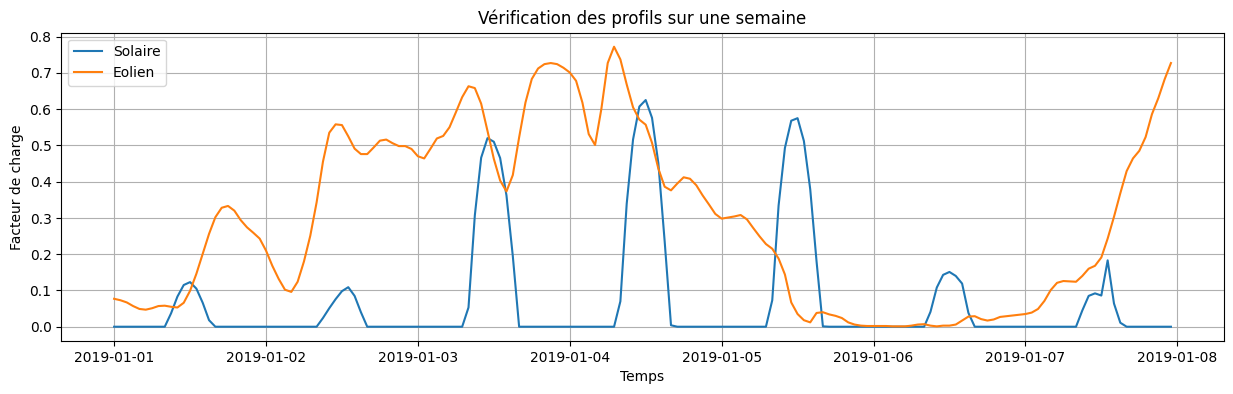

In [10]:
# ==========================================
# Vérification rapide des profils
# ==========================================

plt.figure(figsize=(15,4))
plt.plot(solar["time"].iloc[:168], solar["solar_cf"].iloc[:168], label="Solaire")
plt.plot(wind["time"].iloc[:168], wind["wind_cf"].iloc[:168], label="Eolien")
plt.title("Vérification des profils sur une semaine")
plt.xlabel("Temps")
plt.ylabel("Facteur de charge")
plt.legend()
plt.grid(True)
plt.show()

Consommation annuelle estimée (MWh) : 10073.612193896193
Puissance max estimée (kW) : 1686.7347672120775


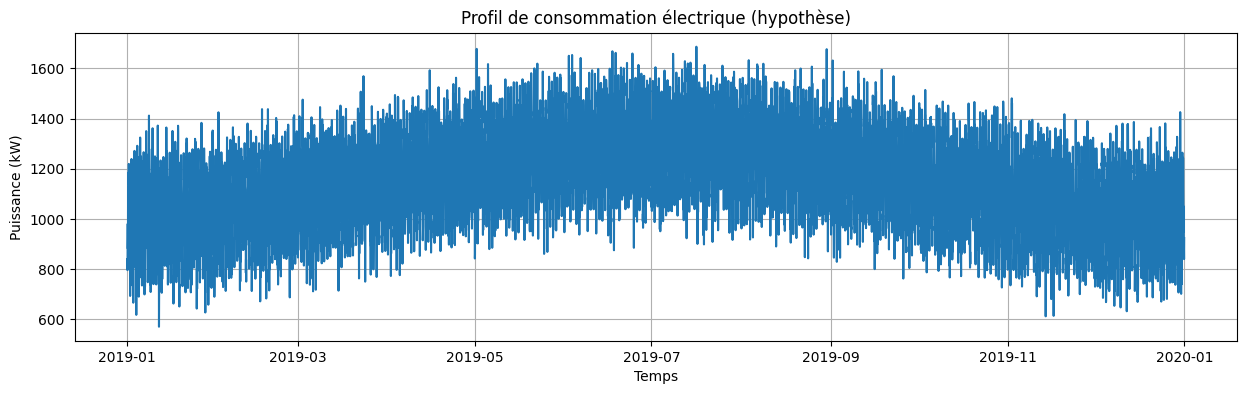

In [11]:
# ==========================================
# Création d'une demande synthétique
# ==========================================

np.random.seed(42)

hours = 8760

base_load = 800
daily_cycle = 200 * (1 + np.sin(2 * np.pi * np.arange(hours) / 24 - np.pi/2))
seasonal_cycle = 150 * (1 + np.sin(2 * np.pi * np.arange(hours) / 8760 - np.pi/2))
random_variation = np.random.normal(0, 80, hours)

demand = base_load + daily_cycle + seasonal_cycle + random_variation
demand = np.clip(demand, 300, 2000)

demand_series = pd.DataFrame({
    "time": solar["time"],
    "demand_kw": demand
})

print("Consommation annuelle estimée (MWh) :", demand_series["demand_kw"].sum() / 1000)
print("Puissance max estimée (kW) :", demand_series["demand_kw"].max())

plt.figure(figsize=(15,4))
plt.plot(demand_series["time"], demand_series["demand_kw"])
plt.title("Profil de consommation électrique (hypothèse)")
plt.xlabel("Temps")
plt.ylabel("Puissance (kW)")
plt.grid(True)
plt.show()

In [12]:
# ==========================================
# Préparation des données pour GBOML
# ==========================================

solar_cf = solar["solar_cf"].clip(lower=0).values
wind_cf = wind["wind_cf"].clip(lower=0).values

# Demande normalisée
demand_norm = demand_series["demand_kw"] / demand_series["demand_kw"].max()

# Hydrolien provisoire
tidal_cf = np.zeros(8760)

print("Longueur solar_cf :", len(solar_cf))
print("Longueur wind_cf  :", len(wind_cf))
print("Longueur demand   :", len(demand_norm))
print("Longueur tidal_cf :", len(tidal_cf))

print("Max demande réelle (kW) :", demand_series['demand_kw'].max())

Longueur solar_cf : 8760
Longueur wind_cf  : 8760
Longueur demand   : 8760
Longueur tidal_cf : 8760
Max demande réelle (kW) : 1686.7347672120775


In [13]:
# ==========================================
# Export des séries vers CSV
# ==========================================

pd.DataFrame(solar_cf).to_csv("data/pure_solar_pv.csv", index=False, header=False)
pd.DataFrame(wind_cf).to_csv("data/pure_wind_offshore.csv", index=False, header=False)
pd.DataFrame(tidal_cf).to_csv("data/pure_tidal.csv", index=False, header=False)
pd.DataFrame(demand_norm).to_csv("data/conso_normalized.csv", index=False, header=False)

print("Fichiers présents dans data :")
print(os.listdir("data"))

Fichiers présents dans data :
['pure_wind_offshore.csv', 'wind_raw.csv', 'solar_raw.csv', 'pure_solar_pv.csv', 'pure_tidal.csv', 'conso_normalized.csv', 'hydro.xlsx', 'hydro_data.xlsx']


In [21]:
# ==========================================
# Vérification de la commande GBOML
# ==========================================

!which gboml
!gboml --help

/usr/local/bin/gboml
usage: gboml [-h] [--lex] [--parse] [--matrix] [--nb_processes NB_PROCESSES]
             [--clp] [--cbc] [--cplex] [--cplex_benders] [--linprog]
             [--gurobi] [--xpress] [--dsp_de] [--dsp_dw] [--highs] [--row_csv]
             [--col_csv] [--json] [--detailed [DETAILED]] [--log]
             [--output OUTPUT] [--opt OPT] [--solver_lib SOLVER_LIB]
             input_file

Compiler and solver for the generic system model language

positional arguments:
  input_file

options:
  -h, --help            show this help message and exit
  --lex                 Prints all tokens found in input file
  --parse               Prints the AST
  --matrix              Prints matrix representation
  --nb_processes NB_PROCESSES
                        Number of processes to use
  --clp                 CLP solver
  --cbc                 CBC solver
  --cplex               Cplex solver
  --cplex_benders       Cplex Benders Solver
  --linprog             Scipy linprog solver
  

In [22]:
# ==========================================
# Exécution du modèle GBOML
# ==========================================

!gboml models/main.gboml --highs --json --output results/run1

Check variables of node penality : --- 0.0001366138458251953 seconds ---
Check variables of node battery : --- 0.00044274330139160156 seconds ---
Check variables of node wind_offshore : --- 0.00011897087097167969 seconds ---
Check variables of node solar_pv : --- 9.942054748535156e-05 seconds ---
Check variables of node tidal : --- 9.298324584960938e-05 seconds ---
Check hyperlink power_balance : --- 7.152557373046875e-07 seconds ---
All --- 0.4396519660949707 seconds ---
Traceback (most recent call last):
  File "/usr/local/bin/gboml", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gboml/gboml_main.py", line 195, in main
    highs_solver(A_eq, b_eq, A_ineq, b_ineq, C_sum, objective_offset, name_tuples,
  File "/usr/local/lib/python3.12/dist-packages/gboml/solver_api/highs_solver.py", line 83, in highs_solver
    highs_model = py_highs.Highs_create()
                  ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12

In [23]:
# ==========================================
# Vérification des fichiers générés
# ==========================================

import os

print("Contenu du dossier results :")
print(os.listdir("results"))

Contenu du dossier results :
[]


In [24]:
# ==========================================
# Recherche des fichiers JSON
# ==========================================

json_files = [f for f in os.listdir("results") if f.endswith(".json")]
print("Fichiers JSON trouvés :", json_files)

Fichiers JSON trouvés : []


In [25]:
# ==========================================
# Lecture du fichier JSON
# ==========================================

import json

if len(json_files) > 0:
    result_file = os.path.join("results", json_files[0])
    print("Fichier lu :", result_file)

    with open(result_file, "r") as f:
        results_json = json.load(f)

    print("Clés principales du JSON :")
    print(results_json.keys())
else:
    print("Aucun fichier JSON trouvé.")

Aucun fichier JSON trouvé.


In [26]:
!pip show gboml

Name: gboml
Version: 0.1.10
Summary: GBOML: Graph-Based Optimization Modeling Language
Home-page: https://gitlab.uliege.be/smart_grids/public/gboml
Author: Bardhyl Miftari, Mathias Berger, Hatim Djelassi, Damien Ernst
Author-email: bmiftari@uliege.be
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, scipy
Required-by: 


In [27]:
!ls /usr/local/bin | grep gboml

gboml


In [28]:
!gboml models/main.gboml --solver highs --json --output results/run1

usage: gboml [-h] [--lex] [--parse] [--matrix] [--nb_processes NB_PROCESSES]
             [--clp] [--cbc] [--cplex] [--cplex_benders] [--linprog]
             [--gurobi] [--xpress] [--dsp_de] [--dsp_dw] [--highs] [--row_csv]
             [--col_csv] [--json] [--detailed [DETAILED]] [--log]
             [--output OUTPUT] [--opt OPT] [--solver_lib SOLVER_LIB]
             input_file
gboml: error: unrecognized arguments: --solver highs


In [29]:
import os
print(os.listdir("results"))

[]


In [30]:
!gboml models/main.gboml --highs --json --output results/run1

Check variables of node penality : --- 0.00017976760864257812 seconds ---
Check variables of node battery : --- 0.0004119873046875 seconds ---
Check variables of node wind_offshore : --- 0.00015234947204589844 seconds ---
Check variables of node solar_pv : --- 0.00014901161193847656 seconds ---
Check variables of node tidal : --- 0.00015592575073242188 seconds ---
Check hyperlink power_balance : --- 9.5367431640625e-07 seconds ---
All --- 0.5156004428863525 seconds ---
Traceback (most recent call last):
  File "/usr/local/bin/gboml", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gboml/gboml_main.py", line 195, in main
    highs_solver(A_eq, b_eq, A_ineq, b_ineq, C_sum, objective_offset, name_tuples,
  File "/usr/local/lib/python3.12/dist-packages/gboml/solver_api/highs_solver.py", line 83, in highs_solver
    highs_model = py_highs.Highs_create()
                  ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/di

In [31]:
import os
print(os.listdir("results"))

[]
